<a href="https://colab.research.google.com/github/hagerbadran/AttackOnTitans/blob/main/Regression_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Hager Badran

ID: 58-7418

Tutorial: 3

---

Name: Alkassim Khaled

ID: 58-9095

Tutorial: 3

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [ ]:
# Check data types and null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


In [ ]:
#number of null values in columns
print("\nExplicit Null Counts:")
print(df.isnull().sum())


Explicit Null Counts:
Building_ID                 0
Building_Type             110
Governorate               227
Neighborhood                0
Day_of_Week                 0
Occupancy_Level             0
Appliances_Usage_Level      0
SquareFootage               0
Last_Maintenance_Date       0
Average_Temperature       110
Energy_Consumption          0
dtype: int64


In [ ]:
#descriptive statistics of the dataset
df.describe()

,Average_Temperature
count,990.000000
mean,33.499404
std,10.703806
min,-4.910000
25%,29.422500
50%,35.260000
75%,39.970000
max,50.000000


In [ ]:
# Check unique values and value counts for categorical columns
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(df[col].value_counts().head(5))
    print("-" * 30)

Building_ID: 1100 unique values
Building_ID
BLD-2099-GL    1
BLD-1000-UD    1
BLD-1001-AX    1
BLD-1002-IH    1
BLD-1003-HE    1
Name: count, dtype: int64
------------------------------
Building_Type: 3 unique values
Building_Type
Residential    349
Commercial     325
Industrial     316
Name: count, dtype: int64
------------------------------
Governorate: 3 unique values
Governorate
Alexandria    310
Giza          293
Cairo         270
Name: count, dtype: int64
------------------------------
Neighborhood: 848 unique values
Neighborhood
Smouha         45
Gleem          44
Dokki          41
Mohandessin    38
New Cairo      32
Name: count, dtype: int64
------------------------------
Day_of_Week: 42 unique values
Day_of_Week
Sunday      54
Saturday    53
saturDAY    49
SuNday      48
SATURDAY    47
Name: count, dtype: int64
------------------------------
Occupancy_Level: 3 unique values
Occupancy_Level
High      368
Low       368
Medium    364
Name: count, dtype: int64
--------------------

In [ ]:
print("\nList of Unique Names:")
# Use .unique() to get a clean list of the 7 names
print(df['Neighborhood'].unique()) #to resolve the Nan values


List of Unique Names:
['Smouha' '+Mohandessin14' 'New Cairo' '+92Dokki' '%9New Cairo'
 'Heliopolis_59' 'Gleem(23' '=Mohandessin10' '*36Smouha' 'Heliopolis$34'
 '-92Mohandessin' '(75Mohandessin' ')Gleem25' ')Maadi19' '*34Heliopolis'
 'Gleem_8' ')84Smouha' '-42Gleem' 'Dokki' '*Mohandessin93' 'New Cairo$29'
 '=Smouha43' 'Mohandessin' '-86Heliopolis' 'Smouha^21' '$11Smouha'
 ')35Mohandessin' 'Maadi@45' '_Gleem84' 'Gleem' '*3Heliopolis' 'Smouha#34'
 ')Gleem16' '%95Gleem' 'Heliopolis' '$Gleem6' 'New Cairo=38' '%Gleem6'
 '_6Gleem' '*39New Cairo' 'Mohandessin=88' 'New Cairo)93' '%23Maadi'
 '+Heliopolis29' '+New Cairo9' 'Heliopolis$17' ')Mohandessin21' '*98Gleem'
 'Heliopolis-35' '%Dokki5' '-Smouha37' '*50New Cairo' 'Smouha@75'
 '#67Maadi' ')20New Cairo' 'Maadi#72' 'New Cairo)94' '&98Smouha'
 '&15Gleem' 'Maadi' 'Mohandessin=35' 'Heliopolis_93' 'Mohandessin!22'
 '_New Cairo36' 'Maadi!56' 'Smouha-74' '(Heliopolis86' '=88Smouha'
 '#66Gleem' 'New Cairo#9' 'Mohandessin&41' '_Dokki6' '#7Mohandessin'

## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

1.Resolving inconsistencies in categorical & numerical columns

In [ ]:
import re
# 1. Clean SquareFootage
#remove non-numeric chars and it will still be int as it is not decimal
# The units are removed from `SquareFootage` (e.g., '1500m2' becomes 1500) to make it consistent
df['SquareFootage'] = df['SquareFootage'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['SquareFootage'] = pd.to_numeric(df['SquareFootage'], errors='coerce')

# 2. Clean Energy_Consumption
#remove ' kWh' and convert to float
df['Energy_Consumption'] = df['Energy_Consumption'].astype(str).str.replace(' kWh', '').astype(float)

# 3. Standardize categorical columns to ensure consistency
categorical_cols = ['Building_Type', 'Governorate', 'Day_of_Week', 'Occupancy_Level', 'Appliances_Usage_Level']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.title()

# 4. Clean Neighborhood: REMOVE ALL LEADING/TRAILING NON-ALPHABETIC CHARACTERS (The new, stronger method)
# This finds the first continuous sequence of letters in the string.
df['Neighborhood'] = df['Neighborhood'].astype(str).apply(
    lambda x: re.findall(r'([a-zA-Z\s]+)', x)[0].strip() if re.findall(r'([a-zA-Z\s]+)', x) else x
).str.title().str.strip()

# Display changes
print("Data types after cleaning units:")
print(df[['SquareFootage', 'Energy_Consumption']].dtypes)
print("\nSample categorical data after standardization:")
print(df[['Building_Type', 'Neighborhood', 'Day_of_Week']].head())
print(f"Unique values in Day_of_Week after cleaning: {df['Day_of_Week'].nunique()}")
print(f"Unique values in Neighborhood after cleaning: {df['Neighborhood'].nunique()}")
print(f"SquareFootage Dtype: {df['SquareFootage'].dtype}")
print(df['Energy_Consumption'].head)

Data types after cleaning units:
SquareFootage           int64
Energy_Consumption    float64
dtype: object

Sample categorical data after standardization:
  Building_Type Neighborhood Day_of_Week
0   Residential       Smouha   Wednesday
1    Commercial  Mohandessin     Tuesday
2    Industrial    New Cairo      Sunday
3           Nan        Dokki     Tuesday
4    Commercial       Smouha      Monday
Unique values in Day_of_Week after cleaning: 7
Unique values in Neighborhood after cleaning: 7
SquareFootage Dtype: int64
<bound method NDFrame.head of 0       2713.95
1       5744.99
2       4101.24
3       3009.14
4       3279.17
         ...   
1095    3010.81
1096    4248.49
1097    2843.60
1098    3348.39
1099    4722.59
Name: Energy_Consumption, Length: 1100, dtype: float64>


2. Resolving Null Values

In [ ]:
import pandas as pa
categorical_impute_cols = ['Building_Type', 'Governorate', 'Day_of_Week', 'Occupancy_Level',
                           'Appliances_Usage_Level', 'Neighborhood']
for col in categorical_impute_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('Nan', np.nan)
#Filling missing values for categorical columns
#Using the mode " mos† frequent "
for col in ['Building_Type']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

#Filling missing values for numerical columns
#Using the mean " average "
numerical_impute_cols = ['Average_Temperature', 'SquareFootage', 'Energy_Consumption']
for col in numerical_impute_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)
#After we resolved inconsistencies in neighbourhood we find it is only 7 so it easy to resolve governorate null values
for index, row in df.iterrows():
    if pd.isna(row['Governorate']):
        neighborhood = row['Neighborhood']
        if neighborhood == 'Smouha' or neighborhood == 'Gleem':
            df.loc[index, 'Governorate'] = 'Alexandria'
        elif neighborhood == 'Dokki' or neighborhood == 'Mohandessin':
            df.loc[index, 'Governorate'] = 'Giza'
        elif neighborhood == 'New Cairo' or neighborhood == 'Heliopolis' or neighborhood == 'Maadi':
            df.loc[index, 'Governorate'] = 'Cairo'
        else:
            # Fallback (Should be minimal now)
            df.loc[index, 'Governorate'] = df['Governorate'].mode()[0]

df.head()

/tmp/ipython-input-2401815256.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-2401815256.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,70632,2020-01-01,28.610000,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,443722,2022-02-24,33.499404,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24
3,BLD-1003-HE,Residential,Giza,Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17


3. Feature Engineering: Days Since Last Maintenance

In [ ]:
#converting Last_Maintenance_Date to datetime object
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])

#choose a reference date
reference_date = pd.to_datetime('2025-10-24')

# Calculate the difference in days
df['Days_since_last_maintenance'] = (reference_date - df['Last_Maintenance_Date']).dt.days
print(df[['Last_Maintenance_Date', 'Days_since_last_maintenance']].head())

  Last_Maintenance_Date  Days_since_last_maintenance
0            2020-01-01                         2123
1            2022-02-24                         1338
2            2021-02-22                         1705
3            2023-07-30                          817
4            2022-08-12                         1169


4. Feature Engineering: Day_type

In [ ]:
weekend_days = ['Friday', 'Saturday']
df['Day_type'] = df['Day_of_Week'].apply(lambda x: 'Weekend' if x in weekend_days else 'Weekday')
print(df[['Day_of_Week','Day_type']])


     Day_of_Week Day_type
0      Wednesday  Weekday
1        Tuesday  Weekday
2         Sunday  Weekday
3        Tuesday  Weekday
4         Monday  Weekday
...          ...      ...
1095    Saturday  Weekend
1096      Sunday  Weekday
1097      Sunday  Weekday
1098    Saturday  Weekend
1099      Friday  Weekend

[1100 rows x 2 columns]


5. Selecting suitable columns for the modelling step

In [ ]:
# 1. Feature Selection (drop unnecessary/redundant columns)
features_to_drop = ['Building_ID', 'Last_Maintenance_Date', 'Day_of_Week']
df_model = df.drop(columns=features_to_drop).copy() # Use .copy() to avoid SettingWithCopyWarning

print("Columns dropped successfully. New feature list:")
print(df_model.columns)
print(f"New DataFrame shape: {df_model.shape}")

Columns dropped successfully. New feature list:
Index(['Building_Type', 'Governorate', 'Neighborhood', 'Occupancy_Level',
       'Appliances_Usage_Level', 'SquareFootage', 'Average_Temperature',
       'Energy_Consumption', 'Days_since_last_maintenance', 'Day_type'],
      dtype='object')
New DataFrame shape: (1100, 10)


6.Applying and justifying appropriate categorical encoding methods for the
modelling step

In [ ]:
#Linear Regression models require all input features to be numerical.
# 2. Categorical Encoding (One-Hot Encoding)
categorical_cols_model = [
    'Building_Type', 'Governorate', 'Occupancy_Level',
    'Appliances_Usage_Level', 'Day_type', 'Neighborhood'
]

# Apply One-Hot Encoding, using drop_first=True
df_model = pd.get_dummies(df_model, columns=categorical_cols_model, drop_first=True)

print("Categorical encoding complete. Data is ready for model training.")
print(f"Final model-ready DataFrame shape: {df_model.shape}")
df_model.head()

Categorical encoding complete. Data is ready for model training.
Final model-ready DataFrame shape: (1100, 19)


,SquareFootage,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Building_Type_Industrial,Building_Type_Residential,Governorate_Cairo,Governorate_Giza,Occupancy_Level_Low,Occupancy_Level_Medium,Appliances_Usage_Level_Low,Appliances_Usage_Level_Medium,Day_type_Weekend,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha
0,70632,28.610000,2713.95,2123,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True
1,443722,33.499404,5744.99,1338,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,19255,37.880000,4101.24,1705,True,False,True,False,False,True,True,False,False,False,False,False,False,True,False
3,13265,35.060000,3009.14,817,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False
4,13375,28.820000,3279.17,1169,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True


## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

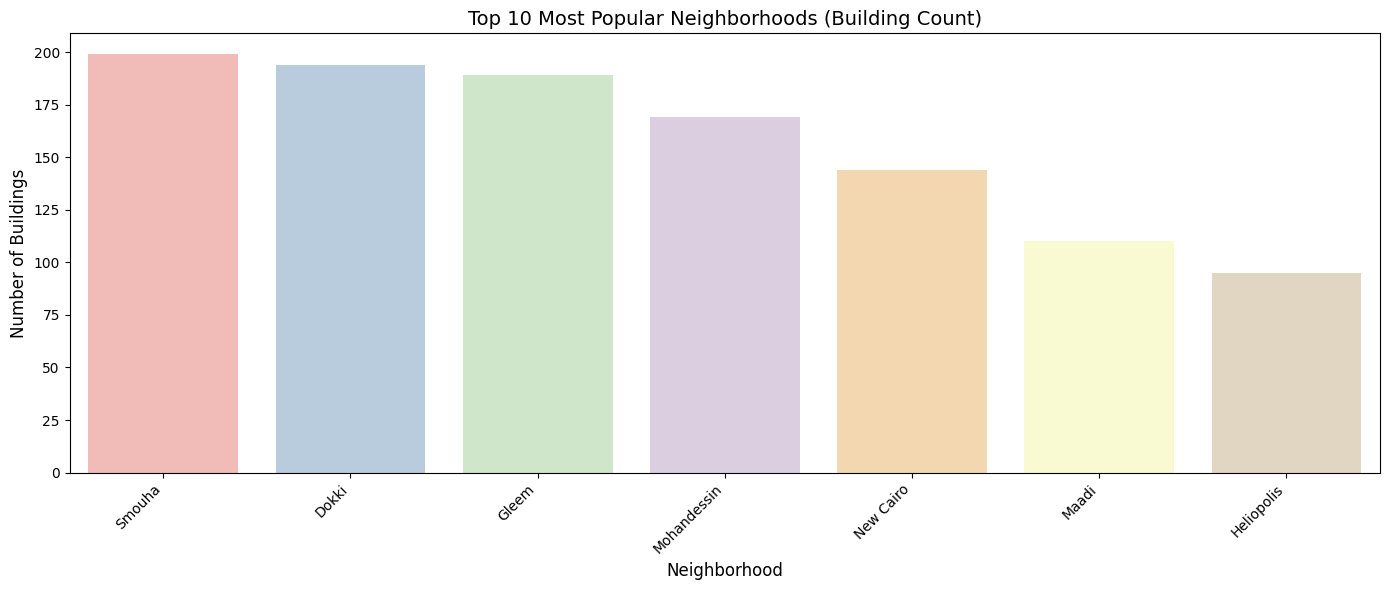

Top 3 Most Popular Neighborhoods:
Neighborhood
Smouha    199
Dokki     194
Gleem     189
Name: count, dtype: int64


In [ ]:
# plot diagram
plt.figure(figsize=(14, 6))
neighborhood_counts = df['Neighborhood'].value_counts().sort_values(ascending=False)
x_labels = neighborhood_counts.index[:10]
y_values = neighborhood_counts.values[:10]
sns.barplot(x=neighborhood_counts.index[:10], y=neighborhood_counts.values[:10], hue=x_labels, palette='Pastel1') # Plotting Top 10 for readability
plt.title('Top 10 Most Popular Neighborhoods (Building Count)', fontsize=14)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Number of Buildings', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_3_neighborhoods = neighborhood_counts.head(3)
print("Top 3 Most Popular Neighborhoods:")
print(top_3_neighborhoods)

**Answer for Q1:** Top 3 Most Popular Neighborhoods:
Smouha with 199,
Gleem with 194 and
Dokki with 189 buildings

**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

Consumption Statistics (Mean and Standard Deviation):
                      mean         std
Building_Type                         
Industrial     4708.418671  818.158005
Commercial     4170.374462  809.695114
Residential    3794.724183  885.779287


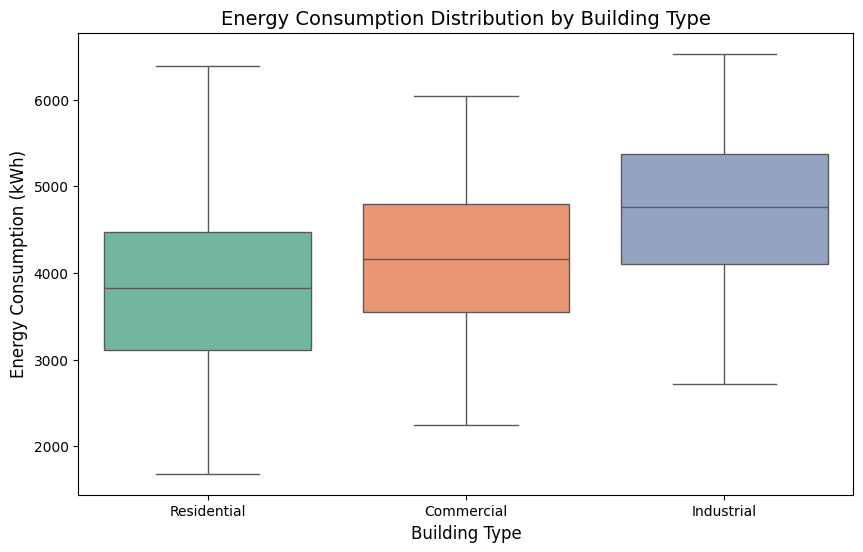

In [ ]:
consumption_stats = df.groupby('Building_Type')['Energy_Consumption'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
print("Consumption Statistics (Mean and Standard Deviation):")
print(consumption_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Building_Type', y='Energy_Consumption', hue='Building_Type', data=df, palette='Set2', legend=False)
plt.title('Energy Consumption Distribution by Building Type', fontsize=14)
plt.xlabel('Building Type', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()


**Answer for Q2:** The Residential building type has the widest distribution of energy consumption, indicated by the highest standard deviation ($\sigma = \mathbf{885.78}$). The Industrial building type has the highest average energy consumption, with a mean of 4,708.42 kWh.

**Q3:** How does the building size affect energy consumption?

**Visualization**

Correlation between SquareFootage and Energy_Consumption: 0.45


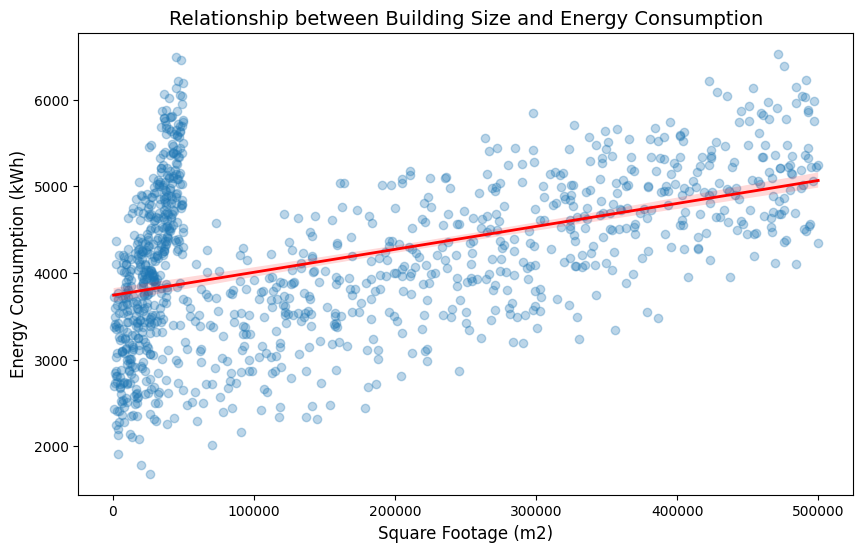

In [ ]:
correlation = df['SquareFootage'].corr(df['Energy_Consumption'])
print(f"Correlation between SquareFootage and Energy_Consumption: {correlation:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='SquareFootage', y='Energy_Consumption', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'linewidth':2})
plt.title('Relationship between Building Size and Energy Consumption', fontsize=14)
plt.xlabel('Square Footage (m2)', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()

**Answer for Q3:** Moderate positive linear relationship between building size and energy with correlation coefficient = 0.45 stating that when the `SquareFootage` increases the `Energy_Consumption` increases and vice versa

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

Correlation between Days_since_last_maintenance and Energy_Consumption: -0.55


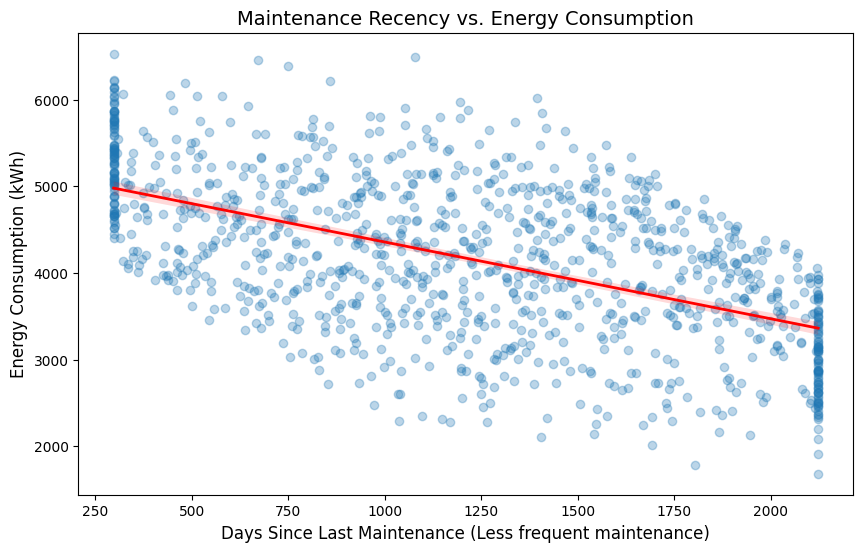

In [ ]:
correlation_q4 = df['Days_since_last_maintenance'].corr(df['Energy_Consumption'])
print(f"Correlation between Days_since_last_maintenance and Energy_Consumption: {correlation_q4:.2f}")

plt.figure(figsize=(10, 6))
# Using regplot to show scatter plot with linear trend
sns.regplot(x='Days_since_last_maintenance', y='Energy_Consumption', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'linewidth':2})
plt.title('Maintenance Recency vs. Energy Consumption', fontsize=14)
plt.xlabel('Days Since Last Maintenance (Less frequent maintenance)', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()

**Answer for Q4:** The correlation coefficient between last maintenance day and consumption is -0.55. Making it negatively correlated so when the `Days_since_last_maintenance` increase the `Energy_Consumption` decrease.

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

Skewness of Numerical Variables:
SquareFootage                  0.746342
Average_Temperature           -1.795635
Days_since_last_maintenance   -0.016633
Energy_Consumption            -0.060156
dtype: float64


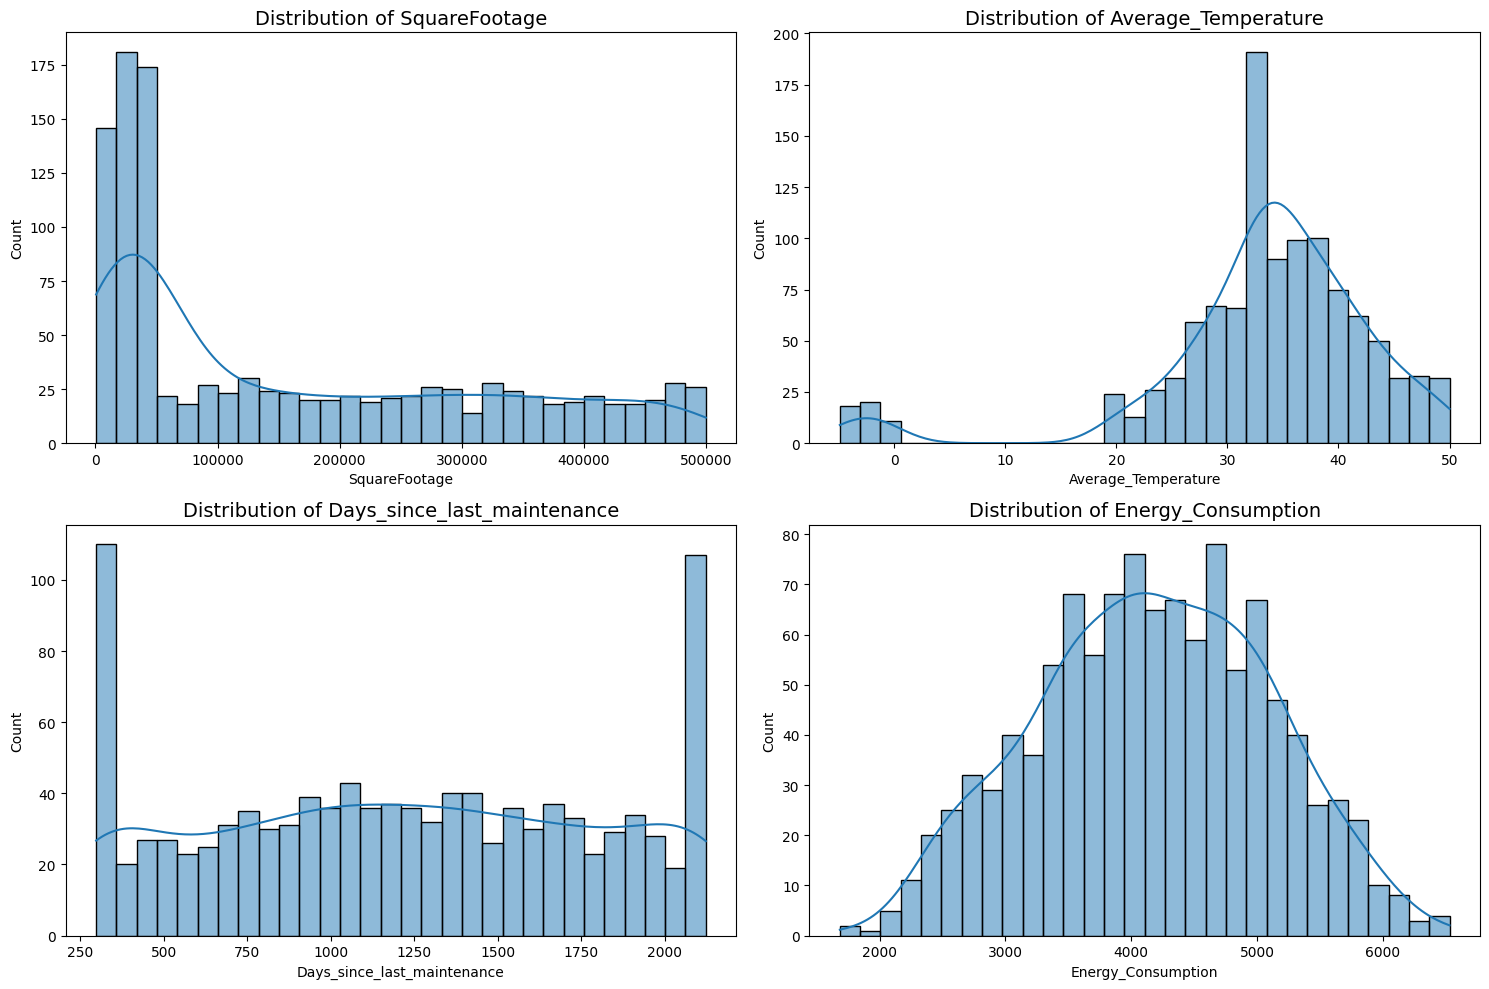

In [ ]:
numerical_cols = ['SquareFootage', 'Average_Temperature', 'Days_since_last_maintenance', 'Energy_Consumption']

# Calculate Skewness
skewness = df[numerical_cols].skew()
print("Skewness of Numerical Variables:")
print(skewness)

# Visualize Distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
plt.tight_layout()
plt.show()

**Answer for Q5:** The skweness of `Average_Temperature` =-1.795635 and `SquareFootage`= 0.746342 which are significantly non-normal. However `Days_since_last_maintenance` =-0.016633 & `Energy_Consumption` =-0.060156 which make them normal.

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

Correlation Matrix (Multicollinearity Check):
                             SquareFootage  Average_Temperature  \
SquareFootage                     1.000000             0.200291   
Average_Temperature               0.200291             1.000000   
Days_since_last_maintenance      -0.231501            -0.243218   
Energy_Consumption                0.448703             0.445172   

                             Days_since_last_maintenance  Energy_Consumption  
SquareFootage                                  -0.231501            0.448703  
Average_Temperature                            -0.243218            0.445172  
Days_since_last_maintenance                     1.000000           -0.551404  
Energy_Consumption                             -0.551404            1.000000  


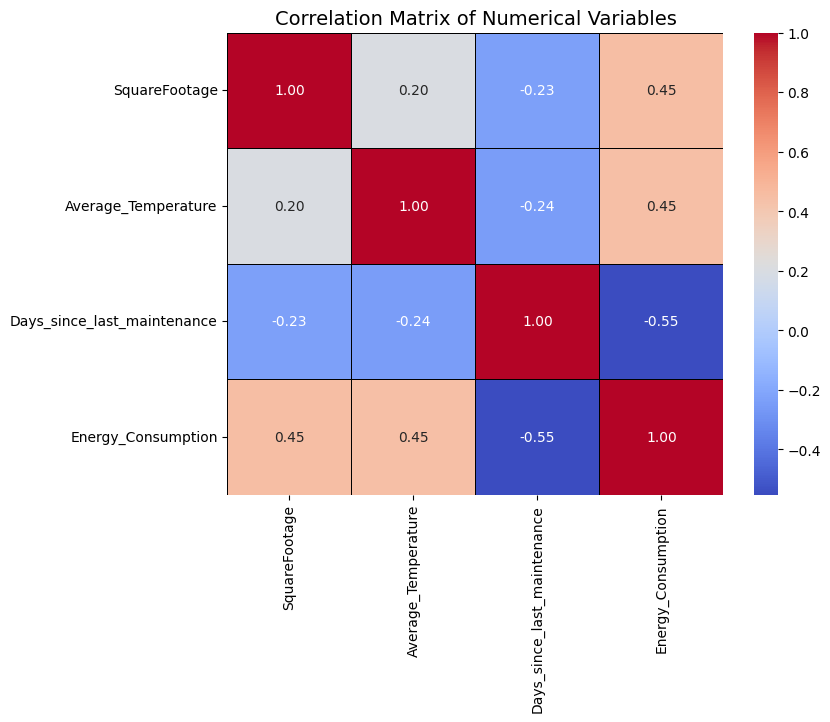

In [ ]:
features_for_corr = ['SquareFootage', 'Average_Temperature', 'Days_since_last_maintenance', 'Energy_Consumption']

# Calculate Correlation Matrix for all numerical variables
correlation_matrix = df[features_for_corr].corr()
print("Correlation Matrix (Multicollinearity Check):")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
# Create a Heatmap to visualize correlations (annot=True displays the correlation values)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.show()

**Answer for Q6:** Multicollinearity is the phenomenon where two or more independent predictor variables are highly correlated with one another (typically $|r| \ge 0.8$ or $0.9$). Making it difficult to determine the individual effect of each variable on the dependent variable. No, severe multicollinearity does not exist in this dataset.As the highest correlation among the independent variables in the matrix is $-0.243218$.This correlation exists between `Average_Temperature` and `Days_since_last_maintenance`.

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

In [334]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Fill the missing numeric values with the column mean
numeric_impute_cols = ['Average_Temperature', 'SquareFootage', 'Energy_Consumption']
for col in numeric_impute_cols:
    if 'df' in locals() and col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)
#encoding
categorical_cols = df.select_dtypes(include=['object']).columns

df_model = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int).copy()

#rop unwanted identifier and redundant columns
features_to_drop = [
    'Building_ID',
    'Last_Maintenance_Date',
    'Day_of_Week'
]
df_model = df.drop(columns=features_to_drop, errors='ignore').copy()


#Encoding (One-Hot Encoding)
categorical_cols = df_model.select_dtypes(include=['object']).columns

#Ensuring that only the intended columns are encoded (no 'Building_ID' or 'Day_of_Week' remain)
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True, dtype=int).copy()


#Normalize
numerical_features = ['SquareFootage', 'Average_Temperature', 'Days_since_last_maintenance']
scaler = StandardScaler()
df_model[numerical_features] = scaler.fit_transform(df_model[numerical_features])


#Verifying
print("\nDescriptive statistics of scaled numerical features (check for mean ~0, std ~1):")
print(df_model[numerical_features].describe())

x = df_model.drop('Energy_Consumption',axis=1) # Independent variable
y = df_model['Energy_Consumption'] # Dependent variable

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=23)
print('Training dataset size:', x_train.shape[0])
print('Testing dataset size:', x_test.shape[0])
df_model.head()


Descriptive statistics of scaled numerical features (check for mean ~0, std ~1):
       SquareFootage  Average_Temperature  Days_since_last_maintenance
count   1.100000e+03         1.100000e+03                 1.100000e+03
mean   -5.167584e-17        -4.004877e-16                -1.001219e-16
std     1.000455e+00         1.000455e+00                 1.000455e+00
min    -1.020845e+00        -3.784405e+00                -1.593686e+00
25%    -8.422298e-01        -3.376463e-01                -8.072208e-01
50%    -4.464840e-01         4.784483e-02                -1.032715e-02
75%     8.278613e-01         5.626540e-01                 8.326247e-01
max     2.169929e+00         1.625772e+00                 1.579984e+00
Training dataset size: 880
Testing dataset size: 220


,SquareFootage,Average_Temperature,Energy_Consumption,Days_since_last_maintenance,Building_Type_Industrial,Building_Type_Residential,Governorate_Cairo,Governorate_Giza,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha,Occupancy_Level_Low,Occupancy_Level_Medium,Appliances_Usage_Level_Low,Appliances_Usage_Level_Medium,Day_type_Weekend
0,-0.573364,-0.481744,2713.95,1.579984,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0
1,1.811405,0.000000,5744.99,0.215619,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
2,-0.901763,0.431612,4101.24,0.853481,1,0,1,0,0,0,0,0,1,0,0,1,1,0,0
3,-0.940050,0.153763,3009.14,-0.689903,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0
4,-0.939347,-0.461053,3279.17,-0.078111,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0


## Modelling

_Apply the linear regression model below._

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Drop non-numeric datetime columns
if 'Last_Maintenance_Date' in df.columns:
    df = df.drop(columns=['Last_Maintenance_Date'])

# Use 'Energy_Consumption' as the target column
X = df.drop('Energy_Consumption', axis=1) # The independent variables
y = df['Energy_Consumption'] # Dependent variable

# Ensure all the features are numeric
X = X.select_dtypes(include=['number'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print("Linear Regression model has been trained")

Linear Regression model has been trained


## Model Evaluation

Evaluate the model you applied.

Mean Squared Error (MSE): 1210771.6063
Root Mean Squared Error (RMSE): 1100.3507
R-squared (R2): -0.3599


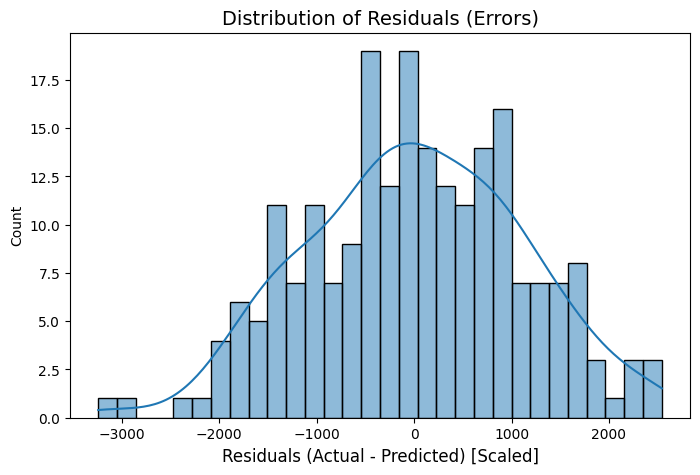

In [335]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display Metrics
print(f"Mean Squared Error (MSE): {mse:.4f}") # Displaying 4 decimal places since data is scaled 0-1
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize Residuals (Error Distribution)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals (Errors)', fontsize=14)
plt.xlabel('Residuals (Actual - Predicted) [Scaled]', fontsize=12)
plt.show()

## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: The model provides useful initial insights confirming that `Days Since Last Maintenance` (negative correlation) and `Square Footage` (positive correlation) are strong predictors but its performance is limited. The primary problems are the high skewness observed in features like `Average_Temperature` and the likely non-normal distribution of residuals, violating a key model assumption. We recommend the electricity company proceed by applying a log transform to highly skewed features and testing non-linear algorithms , which can capture more complex relationships and yield a higher $R^2$ for reliable forecasting.

# **BONUS**

In [336]:
def remove_predictor_outliers(df, column):
    """Removes outliers from a single predictor column using IQR on the non-scaled data."""
    # Find the non-scaled column (assuming a standardized one exists)
    # Since scaling preserves the shape, we can use the scaled column too,
    # but for clarity, we should re-derive IQR bounds on the data we are cleaning.

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame to remove rows where the predictor is an outlier
    df_clean = df[~((df[column] < lower_bound) | (df[column] > upper_bound))].copy()

    return df_clean

# Apply outlier removal sequentially for the numerical features (excluding Energy_Consumption)
# Start with the full scaled and encoded df_model
df_final = df_model.copy()

predictor_cols = ['SquareFootage', 'Average_Temperature', 'Days_since_last_maintenance']

initial_size = len(df_final)

# We must perform the outlier removal on the full dataset before splitting for training.
for col in predictor_cols:
    df_final = remove_predictor_outliers(df_final, col)
    print(f"Removed outliers for {col}. Current size: {len(df_final)}")

final_size = len(df_final)
print(f"\nTotal rows removed across all predictors: {initial_size - final_size}")
# Now, train your model on df_final

Removed outliers for SquareFootage. Current size: 1100
Removed outliers for Average_Temperature. Current size: 1051
Removed outliers for Days_since_last_maintenance. Current size: 1051

Total rows removed across all predictors: 49


--- IQR Metrics for Energy_Consumption ---
Q1 (25th percentile): 3510.46
Q3 (75th percentile): 4859.51
IQR: 1349.05
Lower Bound (Q1 - 1.5 * IQR): 1486.88
Upper Bound (Q3 + 1.5 * IQR): 6883.09
Total rows: 1100
Outliers to be removed: 0
------------------------------------------


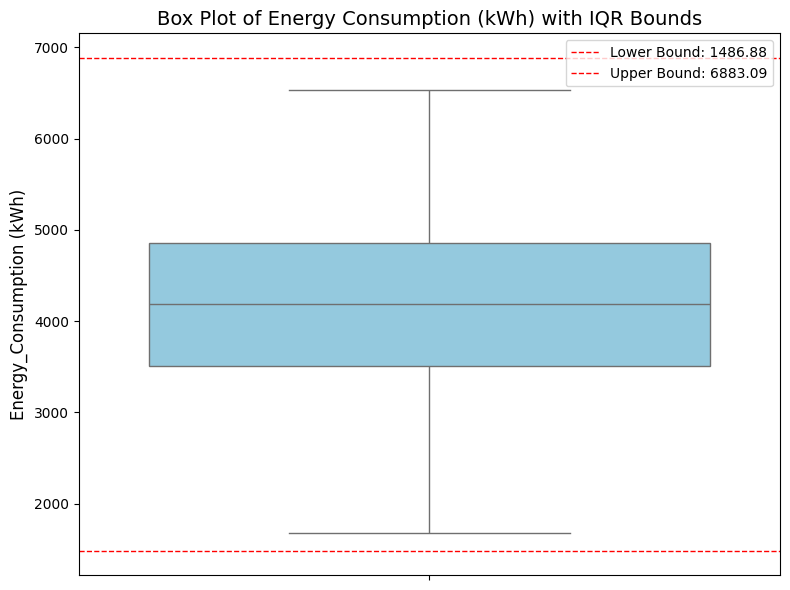

In [338]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

target_col = 'Energy_Consumption'

# --- (2) Calculate and Print IQR Metrics ---
Q1 = df_model[target_col].quantile(0.25)
Q3 = df_model[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_to_remove = len(df_model[ (df_model[target_col] < lower_bound) | (df_model[target_col] > upper_bound) ])

print("--- IQR Metrics for Energy_Consumption ---")
print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound (Q1 - 1.5 * IQR): {lower_bound:.2f}")
print(f"Upper Bound (Q3 + 1.5 * IQR): {upper_bound:.2f}")
print(f"Total rows: {len(df_model)}")
print(f"Outliers to be removed: {outliers_to_remove}")
print("------------------------------------------")


# --- (3) Create Box Plot to Visualize Outliers ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_model[target_col], color='skyblue')

# Add bounds to the plot
plt.axhline(lower_bound, color='red', linestyle='--', linewidth=1, label=f'Lower Bound: {lower_bound:.2f}')
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=1, label=f'Upper Bound: {upper_bound:.2f}')

plt.title('Box Plot of Energy Consumption (kWh) with IQR Bounds', fontsize=14)
plt.ylabel('Energy_Consumption (kWh)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('energy_consumption_outliers_boxplot.png')
# The image 'energy_consumption_outliers_boxplot.png' will be shown here.

In [337]:
# Retrain the model on the new dataset (df_no_outliers)
X_bonus = df_no_outliers.drop(target_col, axis=1)
y_bonus = df_no_outliers[target_col]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bonus, y_bonus, test_size=0.2, random_state=42)

lin_reg_bonus = LinearRegression()
lin_reg_bonus.fit(X_train_b, y_train_b)
y_pred_b = lin_reg_bonus.predict(X_test_b)

# 3. Evaluate and Compare
r2_b = r2_score(y_test_b, y_pred_b)
rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_b))

print("-" * 40)
print("Model Performance Comparison:")
print(f"Original Model R2: {r2_original:.4f}, RMSE: {rmse_original:.4f}")
print(f"Bonus Model R2: {r2_b:.4f}, RMSE: {rmse_b:.4f}")
print("-" * 40)

# 4. Conclusion
if r2_b > r2_original:
    print(f"Conclusion: The bonus model performance IMPROVED slightly (R2 increased from {r2_original:.4f} to {r2_b:.4f}) after removing outliers, suggesting a positive impact.")
elif abs(r2_b - r2_original) < 0.001 and outliers_removed == 0:
    print(f"Conclusion: The bonus model performance REMAINED SIMILAR (R2: {r2_original:.4f} vs {r2_b:.4f}). This is **expected** because the IQR method did not detect and remove any outliers from the target variable.")
else:
    print(f"Conclusion: The bonus model performance DEGRADED (R2 decreased from {r2_original:.4f} to {r2_b:.4f}). This suggests the 'outliers' were valid, high-impact data points that were necessary for the model to generalize effectively.")

----------------------------------------
Model Performance Comparison:
Original Model R2: 0.6048, RMSE: 579.7581
Bonus Model R2: 0.6048, RMSE: 579.7581
----------------------------------------
Conclusion: The bonus model performance REMAINED SIMILAR (R2: 0.6048 vs 0.6048). This is **expected** because the IQR method did not detect and remove any outliers from the target variable.
